<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 12 - Customer Personality Analysis Cluster

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("marketing_campaign.csv")

In [3]:
df.isnull().sum()

,0
Dt_Customer,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Recency,0
MntWines,0


In [4]:
df["Income"].fillna(df["Income"].mean(),inplace=True)

/tmp/ipykernel_3476/1733768805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].mean(),inplace=True)


In [5]:
le = LabelEncoder()

In [6]:
df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])
df

,Dt_Customer,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,04-09-2012,5524,1957,2,4,58138.0,0,0,58,635,...,7,0,0,0,0,0,0,3,11,1
1,08-03-2014,2174,1954,2,4,46344.0,1,1,38,11,...,5,0,0,0,0,0,0,3,11,0
2,21-08-2013,4141,1965,2,5,71613.0,0,0,26,426,...,4,0,0,0,0,0,0,3,11,0
3,10-02-2014,6182,1984,2,5,26646.0,1,0,26,11,...,6,0,0,0,0,0,0,3,11,0
4,19-01-2014,5324,1981,4,3,58293.0,1,0,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,13-06-2013,10870,1967,2,3,61223.0,0,1,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,10-06-2014,4001,1946,4,5,64014.0,2,1,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,25-01-2014,7270,1981,2,2,56981.0,0,0,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,24-01-2014,8235,1956,3,5,69245.0,0,1,8,428,...,3,0,0,0,0,0,0,3,11,0


In [7]:
df.describe()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,2.393750,3.729911,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,1.124797,1.076277,25037.797168,0.538398,0.544538,28.962453,336.597393,39.773434,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,0.000000,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,2.000000,3.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,2.000000,4.000000,51741.500000,0.000000,0.000000,49.000000,173.500000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,3.000000,5.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,4.000000,7.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Dt_Customer          2240 non-null   object 
 1   ID                   2240 non-null   int64  
 2   Year_Birth           2240 non-null   int64  
 3   Education            2240 non-null   int64  
 4   Marital_Status       2240 non-null   int64  
 5   Income               2240 non-null   float64
 6   Kidhome              2240 non-null   int64  
 7   Teenhome             2240 non-null   int64  
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [28]:
X = df.iloc[:,2:29]

In [29]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

In [30]:
X_pca

array([[ 5895.2715543 ,   399.27439281],
       [-5906.19156112,  -280.60781795],
       [19365.69994964,   -73.27876469],
       ...,
       [ 4738.46614229,   537.47775396],
       [16998.25242191,   -20.6230622 ],
       [  619.38014062,  -252.42363751]])

In [31]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.9999432921151248)

In [32]:
from sklearn.cluster import KMeans
distortion =[]
cluster_range = range(1,6)
for i in cluster_range:
  model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # Added n_init to suppress future warnings
  model.fit(X_pca)
  distortion.append(model.inertia_)

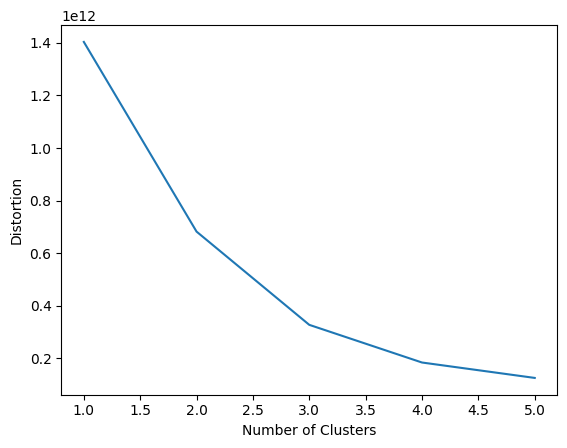

In [33]:
plt.plot(cluster_range,distortion)
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

In [34]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

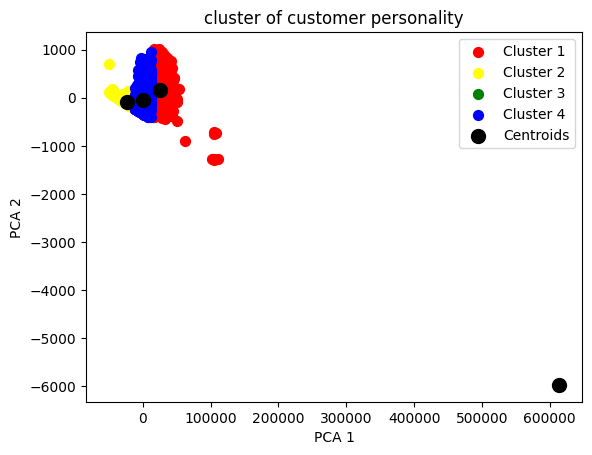

In [35]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red', label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='yellow', label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green', label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=50,c='blue', label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title('cluster of customer personality')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')  #0,1,2  clusters #0,1 pca
plt.legend()
plt.show()